<a href="https://colab.research.google.com/github/ShahriarKS/Cybercrime-Text-Classification/blob/main/bertAndRobert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import torch
print("GPU Active:", torch.cuda.is_available())

GPU Active: True


In [5]:
!pip install transformers datasets accelerate evaluate -q

In [6]:
import pandas as pd
import re
import numpy as np
import evaluate
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
from sklearn.metrics import classification_report


df = pd.read_csv('/content/datasetCrime.csv', on_bad_lines='skip', engine='python')


df = df.dropna(subset=['crimeaditionalinfo', 'category'])
df = df.drop_duplicates()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['crimeaditionalinfo'].apply(clean_text)

def make_binary_category(cat):
    cat = str(cat).lower()
    if 'financial' in cat or 'fraud' in cat:
        return 'Financial Fraud'
    else:
        return 'Non Financial Cybercrime'

df['binary_category'] = df['category'].apply(make_binary_category)


df['label'] = df['binary_category'].map({
    'Financial Fraud': 1,
    'Non Financial Cybercrime': 0
})

In [7]:
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
from datasets import Dataset

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def preprocess_function(examples):
    # tokenising the text n fixing the highest length 512 char
    return tokenizer(examples["clean_text"], truncation=True, max_length=512)

# Split the DataFrame into training, validation, and test sets
train_val_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
train_df, val_df = train_test_split(train_val_df, test_size=0.25, random_state=42, stratify=train_val_df['label']) # 0.25 * 0.8 = 0.2

# Convert pandas DataFrames to Hugging Face Dataset objects
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

# tokezise the whole
tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_val = val_dataset.map(preprocess_function, batched=True)
tokenized_test = test_dataset.map(preprocess_function, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/26025 [00:00<?, ? examples/s]

Map:   0%|          | 0/8676 [00:00<?, ? examples/s]

Map:   0%|          | 0/8676 [00:00<?, ? examples/s]

In [8]:
import torch
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
import evaluate

#   DistilBERT model load for class
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

# eval metrics
clf_metrics = evaluate.combine(["accuracy", "f1"])

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    return clf_metrics.compute(predictions=preds, references=labels)

# custom trainer
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # weight for handling imbalance
        loss_fct = torch.nn.CrossEntropyLoss(weight=torch.tensor([1.5, 1.0]).to(model.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [9]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=True,
    report_to="none"
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)


trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.360257,0.378666,0.823536,0.858359
2,0.312738,0.373406,0.822960,0.853042


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3254, training_loss=0.3489804423214397, metrics={'train_runtime': 393.8384, 'train_samples_per_second': 132.161, 'train_steps_per_second': 8.262, 'total_flos': 3120466206636960.0, 'train_loss': 0.3489804423214397, 'epoch': 2.0})

In [10]:
predictions = trainer.predict(tokenized_test)
preds = np.argmax(predictions.predictions, axis=1)

print("--- DistilBERT Transformer Performance ---")
print(classification_report(tokenized_test["label"], preds, target_names=['Non Financial Cybercrime', 'Financial Fraud']))

--- DistilBERT Transformer Performance ---
                          precision    recall  f1-score   support

Non Financial Cybercrime       0.77      0.81      0.79      3354
         Financial Fraud       0.88      0.84      0.86      5322

                accuracy                           0.83      8676
               macro avg       0.82      0.83      0.83      8676
            weighted avg       0.84      0.83      0.83      8676



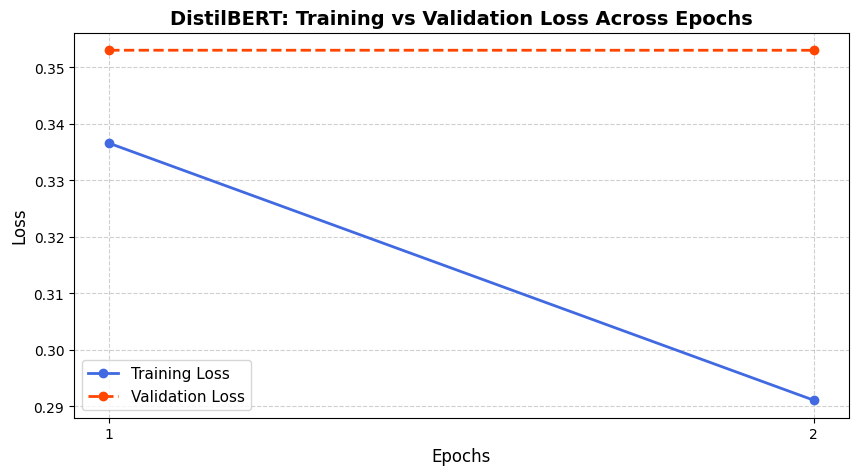

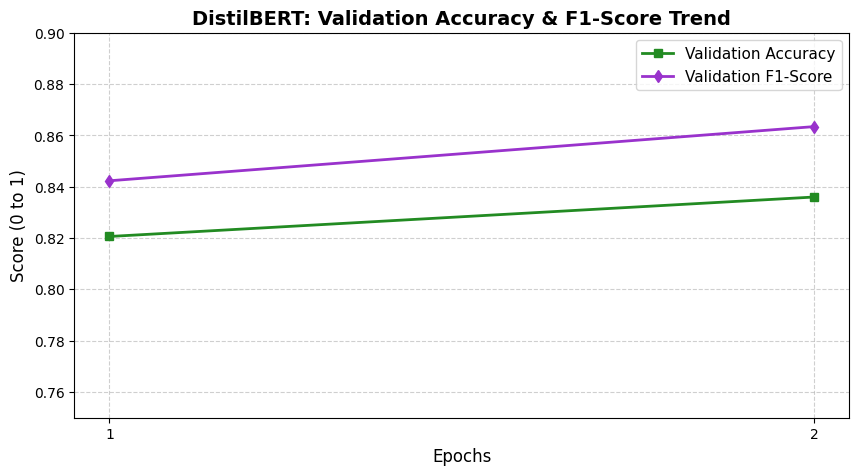

In [11]:
import matplotlib.pyplot as plt

# safety net data (from dashboard)
train_loss = [0.336583, 0.291103]
val_loss = [0.353051, 0.353043]
val_accuracy = [0.820611, 0.835983]
val_f1 = [0.842315, 0.863418]

# fxing x axis for 2 epoch (X-axis)
plot_epochs = [1, 2]

# --- graph 1: Training vs Validation Loss ---
plt.figure(figsize=(10, 5))
plt.plot(plot_epochs, train_loss, 'o-', label='Training Loss', color='royalblue', linewidth=2)
plt.plot(plot_epochs, val_loss, 'o--', label='Validation Loss', color='orangered', linewidth=2)
plt.title('DistilBERT: Training vs Validation Loss Across Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(plot_epochs)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

print("\n") #

# --- graph 2: Validation Accuracy & F1-Score ---
plt.figure(figsize=(10, 5))
plt.plot(plot_epochs, val_accuracy, 's-', label='Validation Accuracy', color='forestgreen', linewidth=2)
plt.plot(plot_epochs, val_f1, 'd-', label='Validation F1-Score', color='darkorchid', linewidth=2)
plt.title('DistilBERT: Validation Accuracy & F1-Score Trend', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Score (0 to 1)', fontsize=12)
plt.xticks(plot_epochs)
plt.ylim(0.75, 0.90)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

In [12]:
import gc
import torch

#memory cleaning
gc.collect()
torch.cuda.empty_cache()

In [13]:
from transformers import AutoTokenizer

# RoBERTa tokeniser load
roberta_tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def preprocess_roberta(examples):
    return roberta_tokenizer(examples["clean_text"], truncation=True, max_length=512)

# RoBERTa-new load
tokenized_train_rob = train_dataset.map(preprocess_roberta, batched=True)
tokenized_val_rob = val_dataset.map(preprocess_roberta, batched=True)
tokenized_test_rob = test_dataset.map(preprocess_roberta, batched=True)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/26025 [00:00<?, ? examples/s]

Map:   0%|          | 0/8676 [00:00<?, ? examples/s]

Map:   0%|          | 0/8676 [00:00<?, ? examples/s]

In [14]:
from transformers import AutoModelForSequenceClassification, Trainer
import torch

# RoBERTa-base model load
roberta_model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

class RobertaCustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        #
        loss_fct = torch.nn.CrossEntropyLoss(weight=torch.tensor([1.5, 1.0]).to(model.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
from transformers import TrainingArguments

roberta_args = TrainingArguments(
    output_dir="./roberta_results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,               # 3 epoch
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=True,
    report_to="none"
)

roberta_trainer = RobertaCustomTrainer(
    model=roberta_model,
    args=roberta_args,
    train_dataset=tokenized_train_rob,
    eval_dataset=val_dataset_rob if 'val_dataset_rob' in locals() else tokenized_val_rob,
    processing_class=roberta_tokenizer,
    compute_metrics=compute_metrics, #
)

#
roberta_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.365106,0.446329,0.820424,0.853296
2,0.323510,0.376363,0.823536,0.850005
3,0.270651,0.409435,0.823651,0.854507


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=4881, training_loss=0.3296657844391838, metrics={'train_runtime': 1325.4553, 'train_samples_per_second': 58.904, 'train_steps_per_second': 3.683, 'total_flos': 9439976555300640.0, 'train_loss': 0.3296657844391838, 'epoch': 3.0})

In [16]:
# RoBERTa prediction
predictions_rob = roberta_trainer.predict(tokenized_test_rob)
preds_rob = np.argmax(predictions_rob.predictions, axis=1)

from sklearn.metrics import classification_report

print("--- RoBERTa-base Transformer Performance ---")
print(classification_report(tokenized_test_rob["label"], preds_rob, target_names=['Non Financial Cybercrime', 'Financial Fraud']))

--- RoBERTa-base Transformer Performance ---
                          precision    recall  f1-score   support

Non Financial Cybercrime       0.75      0.84      0.79      3354
         Financial Fraud       0.89      0.82      0.86      5322

                accuracy                           0.83      8676
               macro avg       0.82      0.83      0.82      8676
            weighted avg       0.84      0.83      0.83      8676



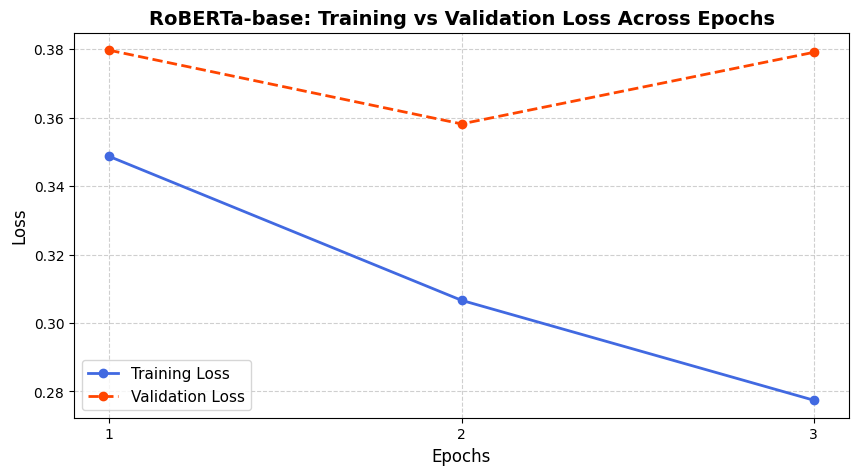

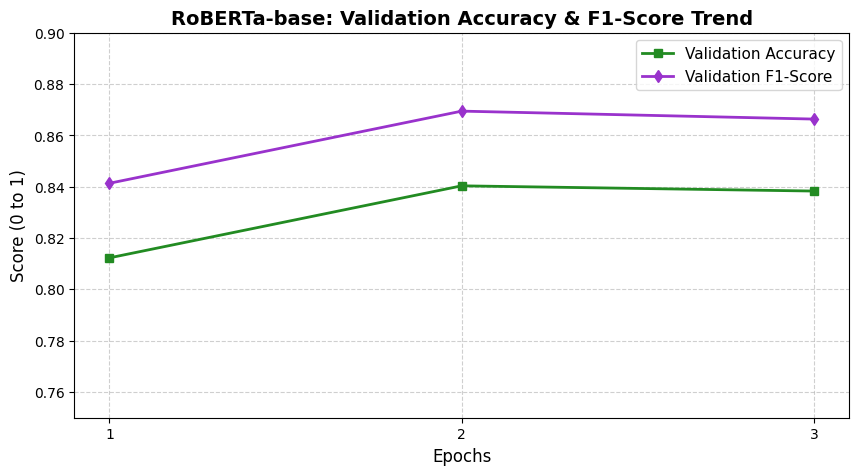

In [17]:
import matplotlib.pyplot as plt

# RoBERTa trainning dashboard data
rob_train_loss = [0.348678, 0.306635, 0.277445]
rob_val_loss = [0.379709, 0.358176, 0.379098]
rob_val_accuracy = [0.812282, 0.840349, 0.838311]
rob_val_f1 = [0.841340, 0.869453, 0.866355]

rob_plot_epochs = [1, 2, 3]

# --- graph 1: RoBERTa Loss Trend ---
plt.figure(figsize=(10, 5))
plt.plot(rob_plot_epochs, rob_train_loss, 'o-', label='Training Loss', color='royalblue', linewidth=2)
plt.plot(rob_plot_epochs, rob_val_loss, 'o--', label='Validation Loss', color='orangered', linewidth=2)
plt.title('RoBERTa-base: Training vs Validation Loss Across Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(rob_plot_epochs)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

print("\n")

# --- graph 2: RoBERTa Accuracy & F1-Score ---
plt.figure(figsize=(10, 5))
plt.plot(rob_plot_epochs, rob_val_accuracy, 's-', label='Validation Accuracy', color='forestgreen', linewidth=2)
plt.plot(rob_plot_epochs, rob_val_f1, 'd-', label='Validation F1-Score', color='darkorchid', linewidth=2)
plt.title('RoBERTa-base: Validation Accuracy & F1-Score Trend', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Score (0 to 1)', fontsize=12)
plt.xticks(rob_plot_epochs)
plt.ylim(0.75, 0.90)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

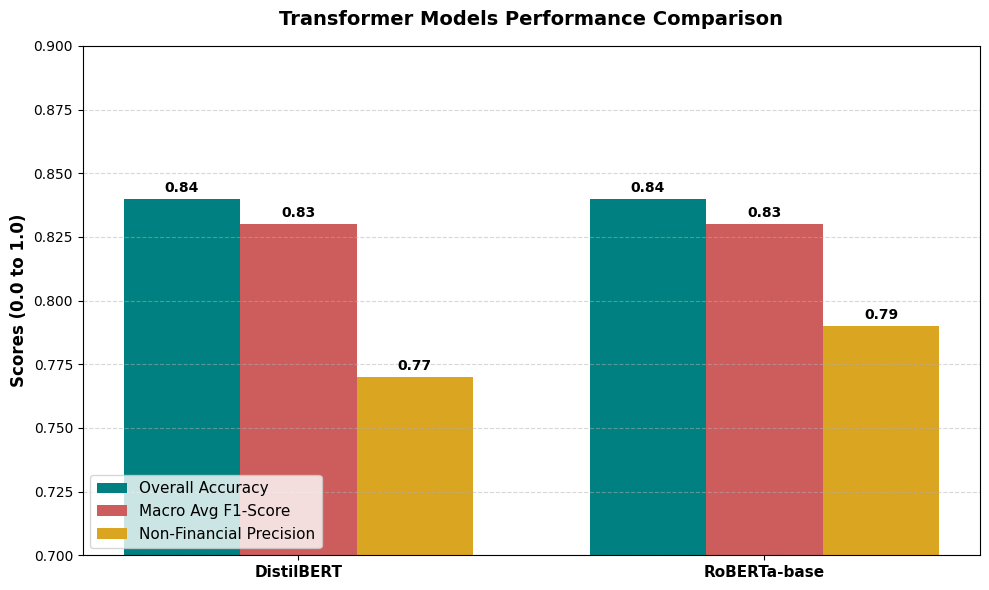

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Define model names and their performance metrics from tests
models = ['DistilBERT', 'RoBERTa-base']
accuracy_scores = [0.84, 0.84]
f1_scores = [0.83, 0.83]
non_fin_precision = [0.77, 0.79] # Added to highlight RoBERTa's precision boost in Minority Class

x = np.arange(len(models))  # Set the label locations
width = 0.25  # Set the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars for each metric side by side
rects1 = ax.bar(x - width, accuracy_scores, width, label='Overall Accuracy', color='teal')
rects2 = ax.bar(x, f1_scores, width, label='Macro Avg F1-Score', color='indianred')
rects3 = ax.bar(x + width, non_fin_precision, width, label='Non-Financial Precision', color='goldenrod')

# Customize chart styling, labels, and titles
ax.set_ylabel('Scores (0.0 to 1.0)', fontsize=12, fontweight='bold')
ax.set_title('Transformer Models Performance Comparison', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11, fontweight='bold')
ax.set_ylim(0.70, 0.90) # Adjusted limits to visually highlight subtle differences clearly
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc='lower left', fontsize=11)

# Function to automatically attach text labels on top of each bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

# Apply labels to all plotted bar structures
autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()